# NAIROBI hOUSING
- In kenya most people live in rental apartments
- The following dataset shows different prices of rental apartments
- We will explore the factors affecting different rental services in Nairobi.
- Based on  this dataset we will train a machine learning model for predictive analysis .

# Dataset Column Descriptions

- **Agency**: The real estate agency or company responsible for listing or managing the property.

- **Neighborhood**: The specific area or locality where the property is located.

- **Price**: The cost of the property, usually expressed in the local currency.

- **Link**: A URL that directs to the full property listing or advertisement online.

- **sq_mtrs**: The total size of the property in square meters.

- **Bedrooms**: The number of bedrooms available in the property.

- **Bathrooms**: The number of bathrooms in the property.

# IMPORT THE LIBRARIES

In [1]:
# import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# LOAD THE DATA INTO THE NOTEBOOK

In [2]:
# load the data into the drive
from google.colab import files
uploaded = files.upload()

Saving rent_apts.csv to rent_apts (2).csv


In [3]:
# load the data into a dataframe
df = pd.read_csv('rent_apts.csv')
df.head()

,Agency,Neighborhood,Price,link,sq_mtrs,Bedrooms,Bathrooms
0,Buy Rent Shelters,"General Mathenge, Westlands","KSh 155,000",/listings/4-bedroom-apartment-for-rent-general...,4.0,4.0,4.0
1,Kenya Classic Homes,"Kilimani, Dagoretti North","KSh 100,000",/listings/3-bedroom-apartment-for-rent-kiliman...,300.0,3.0,4.0
2,Absolute Estate Agents,"Hatheru Rd,, Lavington, Dagoretti North","KSh 75,000",/listings/3-bedroom-apartment-for-rent-lavingt...,3.0,3.0,5.0
3,A1 Properties Limited,"Kilimani, Dagoretti North","KSh 135,000",/listings/3-bedroom-apartment-for-rent-kiliman...,227.0,3.0,4.0
4,Pmc Estates Limited,"Imara Daima, Embakasi","KSh 50,000",/listings/3-bedroom-apartment-for-rent-imara-d...,3.0,3.0,NaN


# EXPLORATORY DATA ANALYSIS

In [4]:
# Check for data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Agency        1848 non-null   object 
 1   Neighborhood  1848 non-null   object 
 2   Price         1848 non-null   object 
 3   link          1848 non-null   object 
 4   sq_mtrs       1846 non-null   float64
 5   Bedrooms      1845 non-null   float64
 6   Bathrooms     1557 non-null   float64
dtypes: float64(3), object(4)
memory usage: 101.2+ KB


In [5]:
# check the last five columns
df.tail(5)

,Agency,Neighborhood,Price,link,sq_mtrs,Bedrooms,Bathrooms
1843,Avic International,"Laikipia Road, Kileleshwa, Dagoretti North","KSh 180,000",/listings/3-bedroom-apartment-for-rent-kileles...,3.0,3.0,NaN
1844,Dmus Realtors,"Peponi road, Spring Valley, Westlands","KSh 180,000",/listings/2-bedroom-apartment-for-rent-spring-...,2.0,2.0,2.0
1845,A1 Properties Limited,"Kileleshwa, Dagoretti North","KSh 180,000",/listings/furnished-4-bedroom-apartment-for-re...,4.0,4.0,5.0
1846,Geoscape Global Limited,"Westlands Area, Westlands","KSh 180,000",/listings/4-bedroom-apartment-for-rent-westlan...,4.0,4.0,4.0
1847,Pmc Estates Limited,"Kilimani, Dagoretti North","KSh 180,000",/listings/2-bedroom-apartment-for-rent-kiliman...,2.0,2.0,NaN


In [6]:
# check the columns
df.columns

Index(['Agency', 'Neighborhood', 'Price', 'link', 'sq_mtrs', 'Bedrooms',
       'Bathrooms'],
      dtype='object')

In [7]:
# check the shape of the dataset
df.shape

(1848, 7)

- The dataset has 1848  rows and 7 columns

# DATA CLEANING

In [8]:
# check for missing values
df.isnull().sum()

,0
Agency,0
Neighborhood,0
Price,0
link,0
sq_mtrs,2
Bedrooms,3
Bathrooms,291


- The dataset has 291 bathroom missing values and 2 square_metres missing values and 3 missing bedroom values

In [9]:
# Handle the missing bathroom values
df['Bathrooms'].fillna(df['Bathrooms'].mean(), inplace=True)
df['Bedrooms'].fillna(df['Bedrooms'].median(), inplace = True)
df['sq_mtrs'].fillna(df['sq_mtrs'].mean(), inplace = True)


In [10]:
# recheck the missing values
df.isnull().sum()

,0
Agency,0
Neighborhood,0
Price,0
link,0
sq_mtrs,0
Bedrooms,0
Bathrooms,0


In [11]:
# clean the price column
df['Price'] = df['Price'].str.replace(',','')
df['Price'] = df['Price'].str.replace('KSh','').astype(float)

In [12]:
# data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Agency        1848 non-null   object 
 1   Neighborhood  1848 non-null   object 
 2   Price         1848 non-null   float64
 3   link          1848 non-null   object 
 4   sq_mtrs       1848 non-null   float64
 5   Bedrooms      1848 non-null   float64
 6   Bathrooms     1848 non-null   float64
dtypes: float64(4), object(3)
memory usage: 101.2+ KB


In [13]:
# check for duplicates
df.duplicated().sum()

np.int64(87)

In [14]:
# drop the duplicates
df.drop_duplicates(inplace=True)

# FEATURE ENGINEERING

In [15]:
# extract the sub  county and estatte from neighbour hood
parts = df['Neighborhood'].str.split(',')

df['sub_county'] = parts.str[-1].str.strip()
df['Estate'] = parts.str[-2].str.strip()

In [16]:
# check the subcounty column
df['sub_county'].head()

,sub_county
0,Westlands
1,Dagoretti North
2,Dagoretti North
3,Dagoretti North
4,Embakasi


In [17]:
df['Estate'].head()

,Estate
0,General Mathenge
1,Kilimani
2,Lavington
3,Kilimani
4,Imara Daima


In [18]:
# drop the neighbourhood
df.drop(columns ='Neighborhood', inplace = True)

In [19]:
# drop the column that  would cause high cardinality
df.drop(columns='link', inplace = True)

# UNIVARIATE ANALYSIS

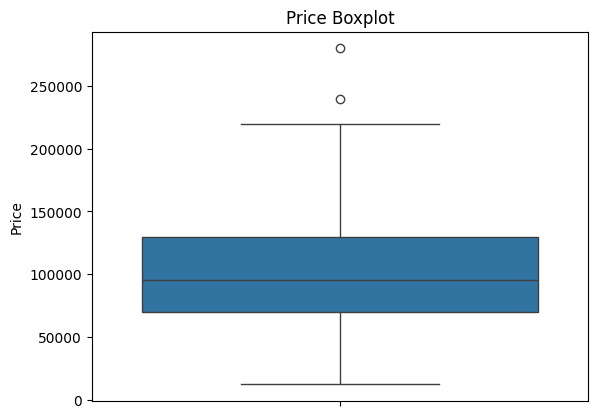

In [20]:
# check for outlier
sns.boxplot(df['Price'])
plt.title('Price Boxplot')
plt.show()

- The data has outlier with values around 240, 000 ksh in apartment price

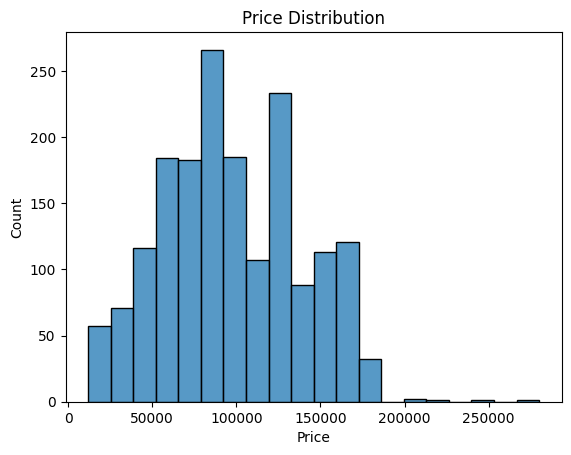

In [21]:
# check for price distribution
sns.histplot(df['Price'], bins=20)
plt.title('Price Distribution')
plt.show()

In [24]:
# perform log transformation
df['Price'] = np.log1p(df['Price'])

# BIVARIATE ANALYSIS

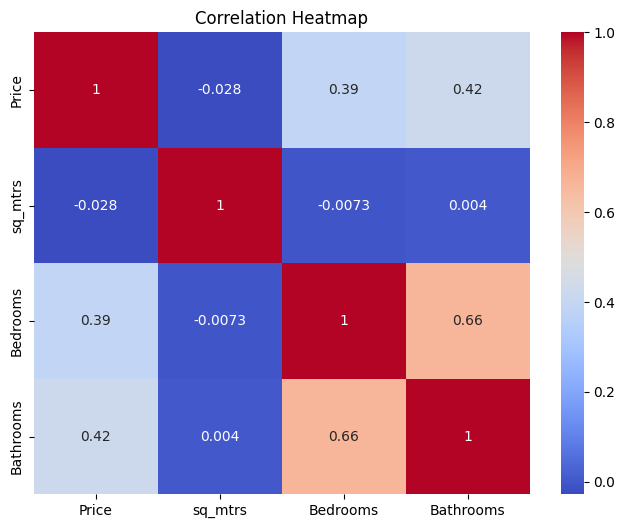

In [26]:
# check the correlations
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_columns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### INTERPRETATION
- Bathrooms  and price have a weak positive correlation meaning the more the
bathrooms the higher the price however this is not only factor.   
- Bedrooms and price have a weak positive correlation and increase in Bedroom  causes and increase in price but  other factors are included.
- sq_mtrs have a weak negative correlation the decrease in sq_mtrs cause a slight decrease in price .
- any value has a strong positive correlation to itself .
- No feature causes multicolinearity

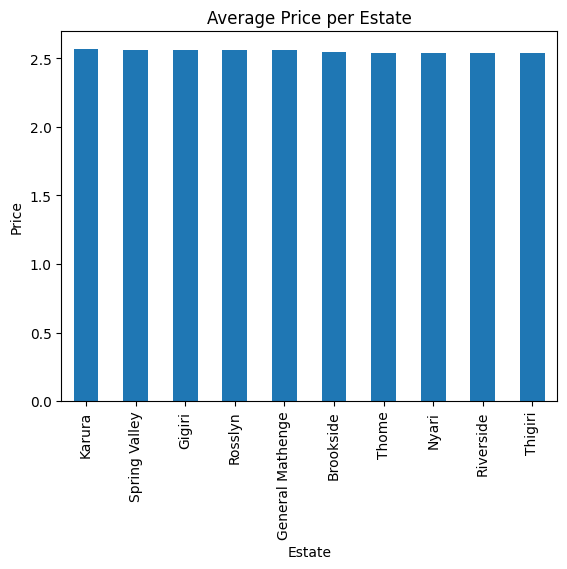

In [27]:
#  categorical values
df.groupby('Estate')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Average Price per Estate')
plt.ylabel('Price')
plt.show()

This estate have the same mean

In [29]:
# subcounty
df.groupby('sub_county')['Price'].mean().sort_values(ascending=False)

,Price
sub_county,
Westlands,2.533981
Muthaiga,2.527527
Dagoretti North,2.522608
Milimani,2.517419
Thika Road,2.515846
Mombasa CBD,2.509268
Ruaraka,2.508769
Mvita,2.497845
Ngong Road,2.486461


In [31]:
# dependent and independent values
X = df.drop(columns='Price')
y = df['Price']

In [32]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [33]:
# create a linear regression pipeline
num_features = ['sq_mtrs', 'Bedrooms', 'Bathrooms']
cat_features = ['Estate', 'sub_county']


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

# Define features
num_features = ['sq_mtrs', 'Bedrooms', 'Bathrooms']
cat_features = ['Estate', 'sub_county']

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train using YOUR split
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sq_mtrs', 'Bedrooms',
                                                   'Bathrooms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Estate', 'sub_county'])])),
                ('model', LinearRegression())])

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.021204462210830544
R2: 0.5562099257786994


- The Linear Regression model achieved an R² score of 0.556, indicating that approximately 55.6% of the variance in house prices is explained by the model. The Mean Absolute Error was low, suggesting that the model predictions are reasonably accurate. The remaining unexplained variance may be due to factors not included in the dataset, such as property condition, amenities, or exact location nuances.

In [36]:
from sklearn.ensemble import RandomForestRegressor
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sq_mtrs', 'Bedrooms',
                                                   'Bathrooms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Estate', 'sub_county'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.02044020439023272
R2: 0.5761153667139799


In [38]:
from xgboost import XGBRegressor
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sq_mtrs', 'Bedrooms',
                                                   'Bathrooms']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Estate', 'sub_county'])...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.020159199427235947
R2: 0.603969128743091


- Three models were evaluated: Linear Regression, Random Forest, and XGBoost. XGBoost achieved the best performance with an R² score of 0.604 and the lowest MAE, indicating improved predictive accuracy. This suggests that while the data contains some non-linear relationships, the overall structure is moderately complex. The model performance could be further improved by incorporating additional features such as property amenities and more detailed location data.